# Sanity check
Confirms the environment works end-to-end: tensors, autograd, a tiny training loop, and a plot.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

print('torch:', torch.__version__, '| cuda:', torch.cuda.is_available())

torch: 2.11.0+cpu | cuda: False


step    0  loss 0.2885


step  400  loss 0.0000


step  800  loss 0.0000


step 1200  loss 0.0000


step 1600  loss 0.0000


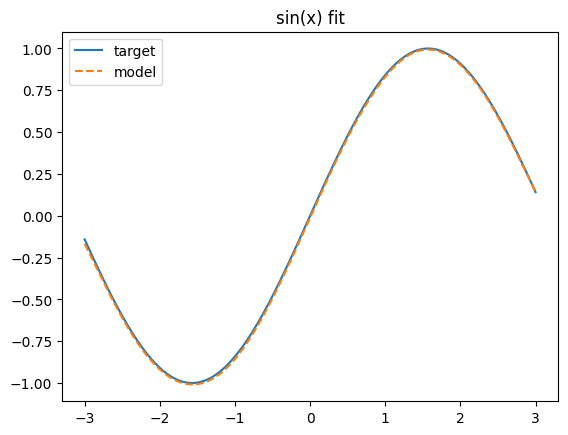

In [2]:
# Fit y = sin(x) with a tiny MLP
torch.manual_seed(0)
x = torch.linspace(-3, 3, 256).unsqueeze(1)
y = torch.sin(x)

model = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 32), nn.Tanh(), nn.Linear(32, 1))
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

for step in range(2000):
    opt.zero_grad()
    loss = loss_fn(model(x), y)
    loss.backward()
    opt.step()
    if step % 400 == 0:
        print(f'step {step:4d}  loss {loss.item():.4f}')

with torch.no_grad():
    pred = model(x)
plt.plot(x, y, label='target')
plt.plot(x, pred, label='model', linestyle='--')
plt.legend(); plt.title('sin(x) fit'); plt.show()